## Test

In [14]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_blobs(n_samples= 100, n_features=2, centers=2, random_state=0)
y = y.reshape(y.shape[0], 1)
y.shape

(100, 1)

In [26]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

def model(X, W, b):
    
    Z = X.dot(W) + b
    A = 1 /(1 + np.exp(-Z))
    
    return A

def log_loss(A, y):
    epsilon = 1e-15 # pour éviter de déterminer le log en 0
    return -1/len(y)*np.sum(y * np.log(A + epsilon) + (1 - y)*np.log(1-A + epsilon))

def gradients(A, X, y):
    
    dW = 1/len(y) * np.dot(X.T, A-y)
    db = 1/len(y) * np.sum(A - y)
    
    return (dW,db)

def update(dW, db, W, b, lr):
    
    W = W - lr * dW
    b = b - lr * db
    
    return (W, b)
def predict(X, W, b):
    
    A = model(X, W, b)
    
    #print('proba:', A)
    
    return A >= 0.5

In [27]:
def nn(X, y, lr = 0.1, n_iter = 100):
    
    #init
    W, b = initialisation(X)
    
    Loss = []
    
    for i in range(n_iter):
        A = model(X, W, b)
        loss = log_loss(A, y)
        Loss.append(loss)
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, lr)
        
    y_pred = predict(X, W, b)
    
    print(accuracy_score(y, y_pred))
    
    plt.plot(Loss)
    plt.show()
    
    return W, b

0.89


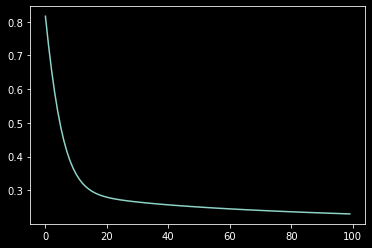

In [24]:
W, b = nn(X, y)

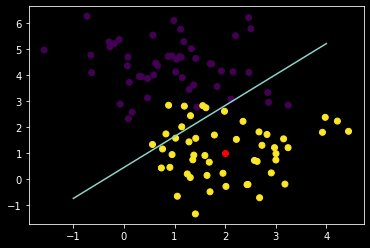

In [6]:
new_plant = np.array([2, 1])
plt.scatter(X[:,0], X[:, 1], c = y)
plt.scatter(new_plant[0], new_plant[1], c='r')
x0 = np.linspace(-1, 4, 100)
x1 = (-W[0]*x0 - b)/W[1]
plt.plot(x0, x1)
plt.show()

In [7]:
predict(new_plant, W, b)

proba: [0.86080316]


array([ True])

## Application

In [8]:
import h5py
import numpy as np


def load_data():
    train_dataset = h5py.File('datasets/trainset.hdf5', "r")
    X_train = np.array(train_dataset["X_train"][:]) # your train set features
    y_train = np.array(train_dataset["Y_train"][:]) # your train set labels

    test_dataset = h5py.File('datasets/testset.hdf5', "r")
    X_test = np.array(test_dataset["X_test"][:]) # your train set features
    y_test = np.array(test_dataset["Y_test"][:]) # your train set labels
    
    return X_train, y_train, X_test, y_test

In [10]:
X_train, y_train, X_test, y_test = load_data()

In [11]:
X_train.shape

(1000, 64, 64)

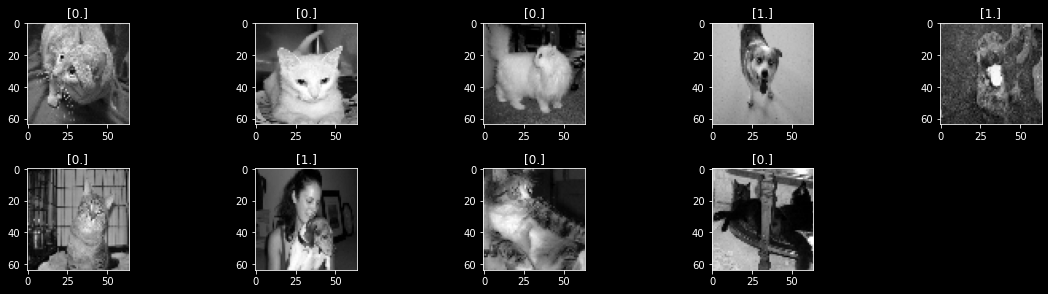

In [15]:
plt.figure(figsize = (16, 8))
for i in range(1, 10):
    plt.subplot(4, 5, i)
    plt.imshow(X_train[i], cmap = 'gray')
    plt.title(y_train[i])
    plt.tight_layout()
plt.show()

***Reshape des données***

In [19]:
X_train_reshape = X_train.reshape(X_train.shape[0], -1)
X_test_reshape = X_test.reshape(X_test.shape[0], -1)

0.509


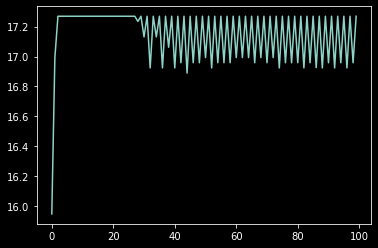

In [28]:
W, b = nn(X_train_reshape, y_train)

***Normalisation des données***

In [30]:
X_train_reshape = X_train_reshape/X_train.max()
X_test_reshape = X_test_reshape/X_test.max()

0.509


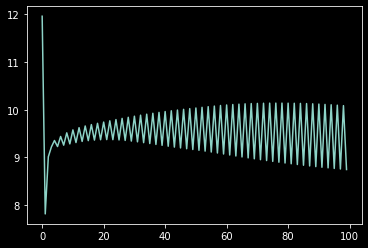

In [31]:
W, b = nn(X_train_reshape, y_train)

0.567


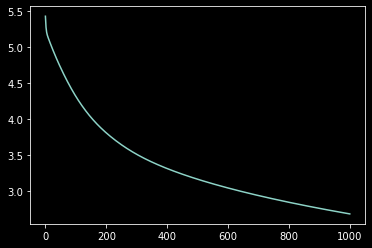

In [34]:
W, b = nn(X_train_reshape, y_train, lr = 0.01, n_iter = 1000)

In [46]:
from tqdm import tqdm

In [58]:
def nn(X_train, X_test, y_train, y_test, lr = 0.1, n_iter = 100):
    
    #init
    W, b = initialisation(X_train)
    
    train_loss = []
    test_loss = []
    train_acc = []
    test_acc = []
    
    for i in tqdm(range(n_iter)):
        #Activation
        A = model(X_train, W, b)
        
        if i%10 == 0 : # faire ce calcul lorsque i est un mutiple de 10
                        # Permet d'accéler le calcul sous python
                
                #Train
            #Calcul du coût
            train_loss.append(log_loss(A, y_train))
            
            #Calcul de la perf
            y_pred_train = predict(X_train, W, b)
            train_acc.append(accuracy_score(y_train, y_pred_train))
            
                #Test
            A_test = model(X_test, W, b)
            #Calcul du coût
            test_loss.append(log_loss(A_test, y_test))
            
            #Calcul de la perf
            y_pred_test = predict(X_test, W, b)
            test_acc.append(accuracy_score(y_test, y_pred_test))
            
        #maj
        dW, db = gradients(A, X_train, y_train)
        W, b = update(dW, db, W, b, lr)
        
    
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label = "train_loss")
    plt.plot(test_loss, label = "test_loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label = "train_acc")
    plt.plot(test_acc, label = "test_acc")
    plt.legend()
    plt.show()
    
    return W, b

100%|██████████| 10000/10000 [01:48<00:00, 92.54it/s]


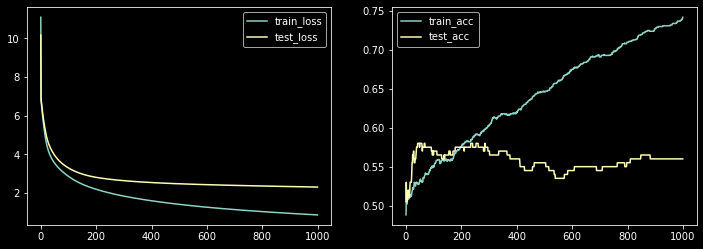

In [60]:
W, b = nn(X_train_reshape, X_test_reshape, y_train, y_test, lr = 0.01, n_iter = 10000)